# Análise exploratória — triagem de reclamações financeiras (CFPB)

Objetivo: entender os dados **antes** de rodar Laya/fine-tuning, para que a análise final tenha
contexto. Nada aqui chama API paga; o que é "modelo" neste notebook é só um baseline clássico
(TF-IDF + regressão logística, segundos em CPU) e a leitura dos resultados do GPT que já existem.

Perguntas que o notebook responde:
1. Como é a base real vs. a amostra do experimento (volume, filas, fraude, cartas-modelo)?
2. Quanto texto cabe no orçamento de tokens do Laya — ele vai decidir "sem ler" parte da reclamação?
3. A tarefa é separável por vocabulário? Um modelo clássico barato já resolve?
4. Onde o GPT erra, e as probabilidades dele são calibradas (importante para a cascata)?
5. O que isso implica para o desenho do experimento e para o post.

In [1]:
import json, os, re, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import snapshot_download
from transformers import AutoTokenizer
from laya.common import build_sequence
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score, classification_report
from common import PRODUCTS, QUESTIONS, MAX_CHARS, map_product, fraud_label
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160, "display.max_colwidth", 120)

# paleta de referência (dataviz skill): azul = série principal, laranja = comparação
BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#0b0b0b", "#52514e"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": MUTED, "axes.labelcolor": INK, "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": .6,
                     "axes.axisbelow": True, "font.size": 9})
QUEUES = list(PRODUCTS)

test = pd.read_parquet("data/test.parquet")
train = pd.read_parquet("data/train.parquet")
raw = pd.read_parquet("data/cfpb_2023plus.parquet")
print(f"bruto 2023+ com narrativa: {len(raw):,} | treino {len(train):,} | teste {len(test):,}")

bruto 2023+ com narrativa: 533,397 | treino 3,600 | teste 1,800


## 1. Base real vs. amostra — e o problema das cartas-modelo

In [2]:
raw["queue"] = [map_product(p, s) for p, s in zip(raw["product"], raw["sub_product"])]
raw["fraud"] = [fraud_label(i, s) for i, s in zip(raw["issue"], raw["sub_issue"])]
txt = raw["consumer_complaint_narrative"]
key = txt.str.lower().map(lambda t: re.sub(r"[^a-z]+", " ", t)[:300])
raw["template_dup"] = key.duplicated(keep=False)

print(f"textos que são cópia (quase) exata de outro: {raw.template_dup.mean():.1%}")
print(f"  em credit_reporting: {raw.loc[raw['queue']=='credit_reporting','template_dup'].mean():.1%}")
print(f"  nas demais filas:    {raw.loc[raw['queue']!='credit_reporting','template_dup'].mean():.1%}")
top = key[raw.template_dup].value_counts().head(5)
print("\nInícios mais repetidos (cartas de 'limpa nome' / credit repair):")
for k, n in top.items():
    print(f"  {n:>6,}x  {k[:110]}...")

textos que são cópia (quase) exata de outro: 58.7%
  em credit_reporting: 71.5%
  nas demais filas:    13.1%

Inícios mais repetidos (cartas de 'limpa nome' / credit repair):
   7,634x  in accordance with the fair credit reporting act the list of accounts below has violated my federally protecte...
   4,111x  i m really not sure what happened i have mailed off letters to the credit bureaus continuously and thus far i ...
   4,000x  my name is xxxx xxxx this complaint is not made in error neither is it being made by a third party i declare u...
   3,951x  i m really not sure what happened i have mailed off letters to the credit bureaus continuously and thus far i ...
   3,575x  my name is xxxx xxxx xxxx this complaint is not made in error neither is it being made by a third party i decl...


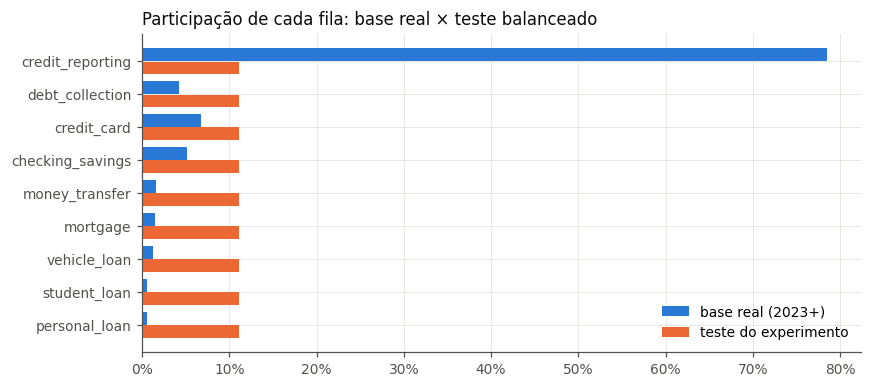

,base real (2023+),teste do experimento
queue,,
credit_reporting,78.5%,11.1%
debt_collection,4.2%,11.1%
credit_card,6.7%,11.1%
checking_savings,5.1%,11.1%
money_transfer,1.6%,11.1%
mortgage,1.5%,11.1%
vehicle_loan,1.3%,11.1%
student_loan,0.5%,11.1%
personal_loan,0.6%,11.1%


In [3]:
real = raw.dropna(subset=["queue"])
dist = pd.DataFrame({"base real (2023+)": real["queue"].value_counts(normalize=True),
                     "teste do experimento": test["queue"].value_counts(normalize=True)}).loc[QUEUES]
fig, ax = plt.subplots(figsize=(8, 3.6))
y = np.arange(len(QUEUES))
ax.barh(y - .2, dist.iloc[:, 0], .38, color=BLUE, label=dist.columns[0])
ax.barh(y + .2, dist.iloc[:, 1], .38, color=ORANGE, label=dist.columns[1])
ax.set_yticks(y, QUEUES); ax.invert_yaxis(); ax.xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
ax.set_title("Participação de cada fila: base real × teste balanceado", loc="left", color=INK)
ax.legend(frameon=False, loc="lower right"); plt.tight_layout(); plt.show()
dist.style.format("{:.1%}")

**Leitura:** na base real, *credit_reporting* domina e boa parte dela é carta-modelo repetida.
O teste é balanceado (200 por fila) de propósito — senão "acertar a fila" viraria "chutar
credit_reporting". Na hora de projetar custo para produção, o volume real importa (seção 7).

In [4]:
fr = pd.DataFrame({
    "fraude na base real": real.dropna(subset=["fraud"]).groupby("queue")["fraud"].mean(),
    "fraude no teste": test.groupby("queue")["fraud"].mean(),
    "positivos no teste": test.groupby("queue")["fraud"].sum()}).loc[QUEUES]
fr.style.format({"fraude na base real": "{:.1%}", "fraude no teste": "{:.1%}", "positivos no teste": "{:.0f}"})

,fraude na base real,fraude no teste,positivos no teste
queue,,,
credit_reporting,0.1%,30.0%,60
debt_collection,14.7%,30.0%,60
credit_card,2.8%,30.0%,60
checking_savings,2.5%,30.0%,60
money_transfer,42.0%,30.0%,60
mortgage,0.0%,0.0%,0
vehicle_loan,4.3%,30.0%,60
student_loan,0.8%,11.0%,22
personal_loan,0.0%,0.0%,0


**Leitura:** fraude se concentra em *money_transfer* (golpes em apps de pagamento) e
*debt_collection* (dívida gerada por roubo de identidade). Em *mortgage* e *personal_loan*
não há positivos — nessas filas a pergunta de fraude só pode errar para o lado do falso positivo.

## 2. Tamanho do texto × orçamento de tokens do Laya

In [5]:
mdir = snapshot_download("convaiinnovations/laya", allow_patterns=["tokenizer/*", "rl_agent_config.json"])
cfg = json.load(open(os.path.join(mdir, "rl_agent_config.json")))
tok = AutoTokenizer.from_pretrained(os.path.join(mdir, "tokenizer"))
print("max_len", cfg["max_len"], "| head_max_len", cfg["head_max_len"])

def budget(text, qid):
    q = QUESTIONS[qid]
    iq = {"t": q["type"], "ins": q["instructions"], "crit": q["criteria"]}
    _, _, st = build_sequence(tok, text, iq, cfg["max_len"], cfg["head_max_len"], return_truncation_stats=True)
    return st

rows = []
for t in test.text:
    full = len(tok(t, add_special_tokens=False)["input_ids"])
    cut = t[:MAX_CHARS]
    p, f = budget(cut, "product"), budget(cut, "fraud")
    rows.append({"chars": len(t), "tokens_full": full, "tokens_1500c": p["state_tokens"],
                 "used_product": p["state_tokens_used"], "used_fraud": f["state_tokens_used"]})
tb = pd.DataFrame(rows)
tb["share_seen_product"] = tb.used_product / tb.tokens_full
tb.describe(percentiles=[.25, .5, .75, .9]).round(1)

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

max_len 512 | head_max_len 192


,chars,tokens_full,tokens_1500c,used_product,used_fraud,share_seen_product
count,1800.0,1800.0,1800.0,1800.0,1800.0,1800.0
mean,1244.4,281.0,201.6,197.7,201.5,0.9
std,1440.8,324.8,113.4,107.4,113.0,0.2
min,101.0,17.0,17.0,17.0,17.0,0.1
25%,427.0,98.8,98.8,98.8,98.8,1.0
50%,851.0,190.5,190.5,190.5,190.5,1.0
75%,1509.2,338.2,314.0,314.0,314.0,1.0
90%,2625.3,586.1,349.0,338.0,349.0,1.0
max,19190.0,4560.0,607.0,338.0,468.0,1.0


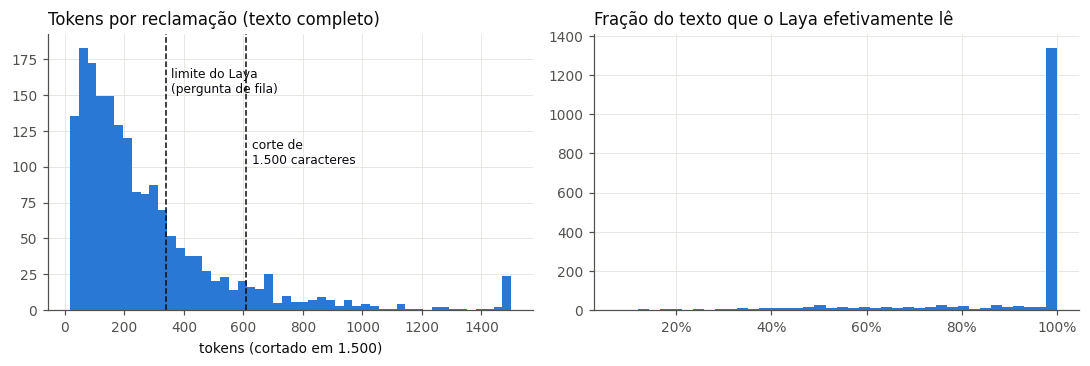

Laya lê o texto inteiro em 73.6% das reclamações
Laya lê menos da metade em 7.8%
Tokens de estado disponíveis — fila: 338 | fraude: 468


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(tb.tokens_full.clip(upper=1500), bins=50, color=BLUE)
for x, lab, h in [(tb.used_product.max(), "limite do Laya\n(pergunta de fila)", .88), (tb.tokens_1500c.max(), "corte de\n1.500 caracteres", .62)]:
    axes[0].axvline(x, color=INK, lw=1, ls="--"); axes[0].text(x + 20, axes[0].get_ylim()[1] * h, lab, color=INK, fontsize=8, va="top")
axes[0].set_title("Tokens por reclamação (texto completo)", loc="left", color=INK); axes[0].set_xlabel("tokens (cortado em 1.500)")
axes[1].hist(tb.share_seen_product.clip(upper=1), bins=40, color=BLUE)
axes[1].set_title("Fração do texto que o Laya efetivamente lê", loc="left", color=INK)
axes[1].xaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
plt.tight_layout(); plt.show()
print(f"Laya lê o texto inteiro em {(tb.share_seen_product >= .999).mean():.1%} das reclamações")
print(f"Laya lê menos da metade em {(tb.share_seen_product < .5).mean():.1%}")
print(f"Tokens de estado disponíveis — fila: {tb.used_product.max()} | fraude: {tb.used_fraud.max()}")

**Leitura:** o orçamento de estado do Laya é curto (512 tokens menos a pergunta e as 9 opções).
Reclamações longas são decididas lendo só o começo. Isso importa para a análise: se o Laya errar
mais nos textos longos, a causa pode ser orçamento, não "inteligência". O GPT recebeu os mesmos
1.500 caracteres, então a comparação é justa no corte de caracteres, mas não no de tokens.

## 3. Qualidade do texto: redações e ruído

In [7]:
def redaction_share(t):
    words = t.split()
    return sum(bool(re.fullmatch(r"[X/{}$.,()\d]*X{2,}[X/{}$.,()\d]*", w)) for w in words) / max(1, len(words))
test["redacted"] = test.text.map(redaction_share)
print(test.redacted.describe(percentiles=[.5, .9, .99]).round(3))
print("\nExemplo curto por fila:")
for q in QUEUES:
    s = test[test["queue"] == q].sort_values("text", key=lambda s: s.str.len()).iloc[len(test[test["queue"] == q]) // 4]
    print(f"\n[{q}] fraude={s.fraud} | {s.issue} / {s.sub_issue}\n  {s.text[:260]}")

count    1800.000
mean        0.050
std         0.064
min         0.000
50%         0.035
90%         0.108
99%         0.314
max         0.863
Name: redacted, dtype: float64

Exemplo curto por fila:

[credit_reporting] fraude=False | Problem with a credit reporting company's investigation into an existing problem / Their investigation did not fix an error on your report
  This is a follow up to # XXXX they results came back as not specified that is un acceptable and it should be delated off my credit report because they did not verify the account just saying not specified when i sent a letter from the court saying they don't re

[debt_collection] fraude=False | Attempts to collect debt not owed / Debt is not yours
  On XXXX of this year I have disputed this account as the car was repoed and I was only the co signer I was never notified that the payments where not being paid until they repoed the car and that was back in 2015 and they refuse to remove it from my credit the

[credit_car

## 4. A tarefa é separável por vocabulário?

In [8]:
vec = TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=50000, sublinear_tf=True,
                      token_pattern=r"(?u)\b[a-wyz][a-z]{2,}\b")  # ignora XXXX
Xtr = vec.fit_transform(train.text.str[:MAX_CHARS]); Xte = vec.transform(test.text.str[:MAX_CHARS])
terms = np.array(vec.get_feature_names_out())

clf_q = LogisticRegression(max_iter=2000, C=5).fit(Xtr, train["queue"])
top_terms = {q: ", ".join(terms[np.argsort(clf_q.coef_[i])[::-1][:10]]) for i, q in enumerate(clf_q.classes_)}
pd.Series(top_terms, name="termos mais indicativos").to_frame()

,termos mais indicativos
checking_savings,"account, bank, checking, opened, deposit, overdraft, chase, checking account, funds, the bank"
credit_card,"card, credit card, credit, the card, synchrony, american express, express, limit, capital one, charges"
credit_reporting,"experian, equifax, transunion, reporting, credit, report, credit report, late, bureaus, score"
debt_collection,"debt, collection, the debt, accounts, this debt, owe, owed, midland, collector, report"
money_transfer,"paypal, money, transfer, venmo, funds, wire, bank, the money, transaction, coinbase"
mortgage,"mortgage, escrow, home, cooper, modification, our, the mortgage, loan, property, house"
personal_loan,"affirm, loan, the loan, netcredit, title, personal loan, personal, one main, line credit, line"
student_loan,"nelnet, loans, navient, student, student loan, loan, mae, sallie, plan, repayment"
vehicle_loan,"car, vehicle, auto, acceptance, finance, the car, credit acceptance, the vehicle, loan, car loan"


In [9]:
clf_f = LogisticRegression(max_iter=2000, C=5, class_weight="balanced").fit(Xtr, train["fraud"])
print("termos que mais indicam fraude:", ", ".join(terms[np.argsort(clf_f.coef_[0])[::-1][:20]]))

termos que mais indicam fraude: opened, fraud, open, identity, name, scammed, fraudulent, scammer, identity theft, theft, credit, scam, stolen, finance charge, bank, down payment, from bank, someone, signature, victim


### Baseline de referência: TF-IDF + regressão logística

Não é um braço do post — é o **piso**. Treina em segundos em CPU com os mesmos 3.600 exemplos que
o fine-tuning do Laya vai usar. Se o Laya fine-tuned não bater isto, a conclusão muda.

In [10]:
pq = clf_q.predict(Xte); pf = clf_f.predict_proba(Xte)[:, 1]
base = {"product_acc": accuracy_score(test["queue"], pq), "product_f1_macro": f1_score(test["queue"], pq, average="macro"),
        "fraud_f1": f1_score(test.fraud, pf >= .5), "fraud_auc": roc_auc_score(test.fraud, pf)}
pd.Series(base).round(3)

product_acc         0.772
product_f1_macro    0.773
fraud_f1            0.634
fraud_auc           0.865
dtype: float64

## 5. Onde o GPT erra (resultados já pagos, só leitura)

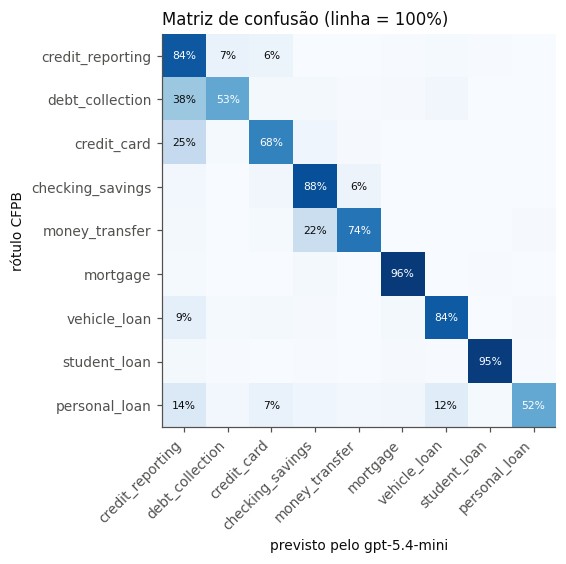

In [11]:
llm = {m: test.merge(pd.read_parquet(f"results/llm_{m}.parquet"), on="id") for m in ["gpt-5.4-nano", "gpt-5.4-mini"]}
mini = llm["gpt-5.4-mini"]
cm = pd.DataFrame(confusion_matrix(mini["queue"], mini.llm_product, labels=QUEUES, normalize="true"), index=QUEUES, columns=QUEUES)
fig, ax = plt.subplots(figsize=(6.4, 5.2))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(9), QUEUES, rotation=45, ha="right"); ax.set_yticks(range(9), QUEUES); ax.grid(False)
for i in range(9):
    for j in range(9):
        if cm.iat[i, j] >= .05:
            ax.text(j, i, f"{cm.iat[i, j]:.0%}", ha="center", va="center", fontsize=7, color="white" if cm.iat[i, j] > .5 else INK)
ax.set_xlabel("previsto pelo gpt-5.4-mini"); ax.set_ylabel("rótulo CFPB")
ax.set_title("Matriz de confusão (linha = 100%)", loc="left", color=INK); plt.tight_layout(); plt.show()

In [12]:
per_q = pd.DataFrame({m: d.groupby("queue").apply(lambda g: (g["queue"] == g.llm_product).mean()) for m, d in llm.items()})
per_q["tfidf"] = pd.Series(pq == test["queue"].values, index=test.index).groupby(test["queue"]).mean()
per_q.loc[QUEUES].style.format("{:.1%}").background_gradient(cmap="Blues", vmin=.4, vmax=1)

,gpt-5.4-nano,gpt-5.4-mini,tfidf
queue,,,
credit_reporting,85.0%,84.5%,66.5%
debt_collection,54.0%,53.0%,70.0%
credit_card,65.0%,68.0%,73.5%
checking_savings,76.0%,88.0%,76.5%
money_transfer,84.0%,73.5%,78.5%
mortgage,93.5%,96.0%,87.5%
vehicle_loan,58.0%,83.5%,76.5%
student_loan,91.0%,95.0%,91.5%
personal_loan,48.5%,52.5%,74.5%


In [13]:
nano = llm["gpt-5.4-nano"]
both = mini.merge(nano[["id", "llm_product"]], on="id", suffixes=("_mini", "_nano"))
agree = both.llm_product_mini == both.llm_product_nano
print(f"nano e mini concordam em {agree.mean():.1%} das reclamações")
print(f"  quando concordam, acertam {(both.llm_product_mini[agree] == both['queue'][agree]).mean():.1%}")
print(f"  quando discordam, o mini acerta {(both.llm_product_mini[~agree] == both['queue'][~agree]).mean():.1%}")

mini["len_bucket"] = pd.qcut(mini.text.str.len(), 4, labels=["curto", "médio", "longo", "muito longo"])
mini.groupby("len_bucket").apply(lambda g: pd.Series({"acc_fila": (g["queue"] == g.llm_product).mean(),
                                                     "n": len(g), "chars_mediana": g.text.str.len().median()})).round(3)

nano e mini concordam em 82.7% das reclamações
  quando concordam, acertam 82.3%
  quando discordam, o mini acerta 52.4%


,acc_fila,n,chars_mediana
len_bucket,,,
curto,0.729,451.0,270.0
médio,0.748,449.0,635.0
longo,0.780,450.0,1136.5
muito longo,0.827,450.0,2287.0


**Leitura sobre o teto:** parte do "erro" é do rótulo — o consumidor escolhe o produto no formulário
e uma reclamação sobre cobrança de dívida que aparece no relatório de crédito pode legitimamente
cair em qualquer das duas filas. Os pares mais confundidos acima delimitam esse teto.

## 6. Probabilidade de fraude do GPT é calibrada? (base da cascata)

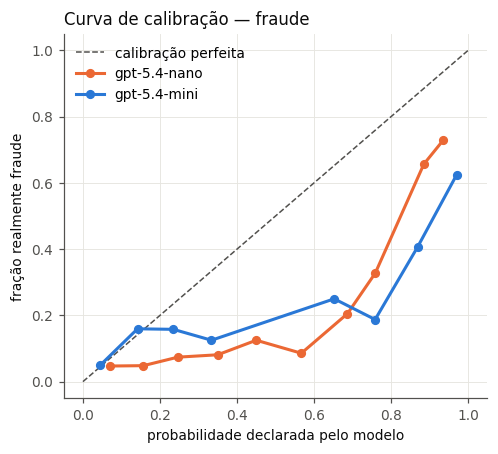

gpt-5.4-nano valores distintos de fraud_probability: 36 | AUC 0.853
gpt-5.4-mini valores distintos de fraud_probability: 60 | AUC 0.868


In [14]:
fig, ax = plt.subplots(figsize=(4.6, 4.2))
ax.plot([0, 1], [0, 1], color=MUTED, lw=1, ls="--", label="calibração perfeita")
for (m, d), c in zip(llm.items(), [ORANGE, BLUE]):
    b = pd.cut(d.llm_fraud_p, np.linspace(0, 1, 11), include_lowest=True)
    r = d.groupby(b).agg(p=("llm_fraud_p", "mean"), y=("fraud", "mean"), n=("fraud", "size")).dropna()
    ax.plot(r.p, r.y, marker="o", ms=5, lw=2, color=c, label=m)
ax.set_xlabel("probabilidade declarada pelo modelo"); ax.set_ylabel("fração realmente fraude")
ax.set_title("Curva de calibração — fraude", loc="left", color=INK); ax.legend(frameon=False); plt.tight_layout(); plt.show()
for m, d in llm.items():
    print(m, "valores distintos de fraud_probability:", d.llm_fraud_p.round(2).nunique(), "| AUC", round(roc_auc_score(d.fraud, d.llm_fraud_p), 3))

**Leitura:** LLMs "falam" probabilidades redondas (0,1 / 0,9) — são poucas faixas distintas e
normalmente mal calibradas. O argumento do Laya/Jev é justamente devolver probabilidade treinada
com *proper scoring rule*. Se a curva do Laya ficar mais perto da diagonal, isso é um ponto
concreto do post (limiar de confiança confiável = cascata que funciona).

## 7. Latência e custo do LLM — e a projeção para volume real

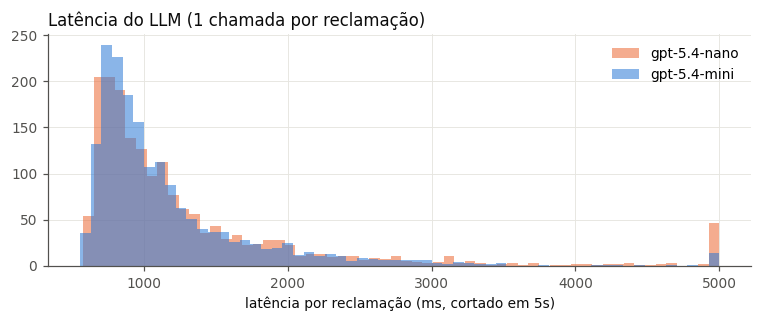

,tokens_in_médio,tokens_out_médio,US$_por_1M_reclamações,p50_ms,p95_ms
gpt-5.4-nano,517.6,26.4,136.6,1011.0,3158.2
gpt-5.4-mini,517.6,27.5,511.8,961.2,2403.4


In [15]:
fig, ax = plt.subplots(figsize=(7, 3))
for (m, d), c in zip(llm.items(), [ORANGE, BLUE]):
    ax.hist(d.llm_ms.clip(upper=5000), bins=60, alpha=.55, color=c, label=m)
ax.set_xlabel("latência por reclamação (ms, cortado em 5s)"); ax.legend(frameon=False)
ax.set_title("Latência do LLM (1 chamada por reclamação)", loc="left", color=INK); plt.tight_layout(); plt.show()

cost = pd.DataFrame({m: {"tokens_in_médio": d.tok_in.mean(), "tokens_out_médio": d.tok_out.mean(),
                         "US$_por_1M_reclamações": d.cost_usd.mean() * 1e6,
                         "p50_ms": d.llm_ms.median(), "p95_ms": d.llm_ms.quantile(.95)} for m, d in llm.items()}).T
cost.round(1)

In [16]:
# ordem de grandeza: volume anual de reclamações na CFPB (base real, todas as filas, 2023)
vol_2023 = (raw.date.dt.year == 2023).sum()
print(f"reclamações com narrativa publicadas em 2023: {vol_2023:,}")
for m in cost.index:
    print(f"  {m}: US$ {cost.loc[m, 'US$_por_1M_reclamações'] * vol_2023 / 1e6:,.0f} por ano só para triar (2 decisões)")

reclamações com narrativa publicadas em 2023: 413,724
  gpt-5.4-nano: US$ 57 por ano só para triar (2 decisões)
  gpt-5.4-mini: US$ 212 por ano só para triar (2 decisões)


## 8. Implicações para o experimento e para o post

Números desta execução (29/09/2026):

1. **Cartas-modelo dominam a base real.** 58,7% das reclamações 2023+ são cópia (quase) exata de
   outra — 71,5% em *credit_reporting* (cartas de "limpa nome"). Sem deduplicar, qualquer modelo
   "acerta" decorando template e a métrica infla. Já removidas do experimento.

2. **O piso é alto: TF-IDF + regressão logística empata com o GPT-5.4-mini.** Com os mesmos 3.600
   exemplos que o Laya vai usar no fine-tuning, em segundos de CPU: 77,2% na fila (mini: 77,1%),
   AUC de fraude 0,865 (mini: 0,868). A comparação justa do Laya fine-tuned é contra *este* piso,
   não só contra o LLM zero-shot. Isso vira argumento do post: "antes da arquitetura nova, o
   baseline de 20 linhas".

3. **O teto é baixo por causa do rótulo.** Os erros se concentram em pares legítimos:
   *debt_collection → credit_reporting* (dívida que aparece no relatório), *credit_card →
   credit_reporting*, *money_transfer → checking_savings*. Filas com vocabulário próprio
   (*mortgage*, *student_loan*) passam de 95%. O ganho possível está em ~4 filas.

4. **Orçamento de tokens do Laya é real, mas não dominante.** Ele lê o texto inteiro em 73,6% das
   reclamações; menos da metade em 7,8%. Porém o GPT acerta *mais* nos textos longos (83% vs 73%
   nos curtos) — justamente onde o Laya corta. Analisar o Laya por faixa de tamanho.

5. **GPT é superconfiante em fraude.** Quando declara ~0,9, a fração real de fraude é ~0,6–0,7;
   quando declara ~0,6, é ~0,2. Probabilidade de LLM não serve como limiar de cascata sem
   recalibração. É aqui que o Laya (treinado com *proper scoring rule* + temperatura) pode ganhar
   de forma demonstrável — e é o ponto mais "sênior" do post.

6. **Concordância nano × mini é um sinal de confiança barato:** concordam em 82,7% e, quando
   concordam, acertam 82,3%; quando discordam, o mini acerta 52,4%.

7. **Custo, na escala da CFPB, não é o argumento.** Triar ~414 mil reclamações/ano custaria
   US$ 57 (nano) a US$ 212 (mini). O argumento de custo só aparece em volume de milhões por dia
   (transações, mensagens de app, eventos de fraude). Para *reclamações*, os argumentos fortes são
   **latência** (~1 s p50 e 2,4–3,2 s p95 do LLM vs. dezenas de ms), **calibração** e **dado que
   não sai de casa** (regulado: LGPD, sigilo bancário). O post deve dizer isso explicitamente — e
   projetar o custo para um cenário de alto volume em vez de vender economia onde ela é irrelevante.